# Sobol Sampling for Sensitivity Analysis on AlphaPEM
 
In this step, we directly generate the parameter samples needed for first- and second-order Sobol sensitivity analysis of the **AlphaPEM** model.

 - We work with a configuration file (`param_config.yaml`) that defines the ranges for all input parameters.
 - We include handling for **dependent parameters**, e.g., `Pc_des = Pa_des - 20000`.
 - The final output is a Pandas DataFrame (`df_sobol_samples`) with `2N*(D + 2)` rows (where `D` is the number of parameters).
 
This matrix can then be passed to the AlphaPEM model to evaluate polarization curves and compute sensitivity indices.

In [208]:
import os
import sys
import numpy as np
import pandas as pd
import hashlib
from omegaconf import OmegaConf
from SALib.sample import saltelli
from SALib.sample.sobol import sample as sobol_sample
from SALib.analyze import sobol

# Custom modules
sys.path.append("../external/AlphaPEM")
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.validity.validity_criteria import validate_polarization_curves

In [54]:
def compute_region_auc(row, ifc_cols, ucell_cols, region_bounds, handle_negative="drop"):
    """
    Compute the discrete AUC for one region of the polarization curve.

    Parameters
    ----------
    row : pd.Series
        One row from the dataset.
    ifc_cols : list of str
        Columns containing current density values.
    ucell_cols : list of str
        Columns containing voltage values.
    region_bounds : tuple
        Tuple (lower_bound, upper_bound) for the region.
    handle_negative : str
        What to do with negative voltages:
        - 'drop': ignore (mask out) those points
        - 'zero': replace them with 0
        - 'keep': use as-is (default behavior)

    Returns
    -------
    float or np.nan
        Computed area under the curve for the given region.
    """
    import numpy as np

    ifcs = row[ifc_cols].values
    volts = row[ucell_cols].values
    mask_region = (ifcs >= region_bounds[0]) & (ifcs < region_bounds[1])

    if not np.any(mask_region):
        return np.nan

    region_ifcs = ifcs[mask_region]
    region_volts = volts[mask_region]

    if handle_negative == "drop":
        mask_valid = region_volts >= 0
        region_ifcs = region_ifcs[mask_valid]
        region_volts = region_volts[mask_valid]
    elif handle_negative == "zero":
        region_volts = np.maximum(region_volts, 0)

    if len(region_ifcs) < 2:
        return np.nan  # Need at least two points to integrate

    return np.trapezoid(region_volts, region_ifcs)

In [27]:
# -------------------------------------
# Load parameter configuration
# -------------------------------------
config_path = '../param_config.yaml'
parameter_ranges = OmegaConf.load(config_path)
param_dict = dict(parameter_ranges)
print(f"Loaded the parameter ranges for {len(param_dict)} input features.")
print(param_dict)

Loaded the parameter ranges for 13 input features.
{'Tfc': [333, 363], 'Pa_des': [130000.0, 300000.0], 'Sc': [1.1, 3.0], 'Phi_c_des': [0.1, 0.7], 'epsilon_gdl': [0.55, 0.8], 'tau': [1.0, 4.0], 'epsilon_mc': [0.15, 0.4], 'epsilon_c': [0.15, 0.3], 'e': [3, 4, 5], 'Re': [5e-07, 5e-06], 'i0_c_ref': [0.001, 80], 'kappa_co': [15, 40], 'kappa_c': [0, 2.5]}


In [32]:
# -------------------------------------
# Identify discrete parameters
# -------------------------------------
discrete_values_dict = {}
processed_bounds = {}

for param, values in param_dict.items():
    if len(values) > 2:
        # Discrete: Store list of valid values, use min/max as bounds
        discrete_values_dict[param] = values
        processed_bounds[param] = [min(values), max(values)]
    else:
        # Continuous: Use as-is
        processed_bounds[param] = values

In [63]:
# -------------------------------------
# Define SALib problem dictionary
# -------------------------------------
param_names = list(processed_bounds.keys())
bounds = [processed_bounds[name] for name in param_names]

problem = {
    'num_vars': len(param_names),
    'names': param_names,
    'bounds': bounds
}

In [185]:
# -------------------------------------
# Generate Sobol Samples
# -------------------------------------
N = 2048

X = sobol_sample(problem, N, calc_second_order=True, seed=42)

# Convert to DataFrame
df_param_values = pd.DataFrame(X, columns=param_names)
df_param_values.head()

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c
0,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
1,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
2,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
3,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265
4,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,4.612458,0.000001,42.263896,31.826572,0.95265


In [228]:

# -------------------------------------
# Post-process discrete variables
# -------------------------------------
df_param_values_final = df_param_values.copy()

for param, valid_values in discrete_values_dict.items():
    df_param_values_final[param] = df_param_values_final[param].apply(
        lambda x: min(valid_values, key=lambda v: abs(v - x))
    )

# -------------------------------------
# Add dependent parameters
# -------------------------------------
df_param_values_final["Pc_des"] =  df_param_values_final["Pa_des"] - 20000

In [229]:
def row_hash(row):
    row_str = '|'.join([f"{x:.8g}" for x in row])
    return hashlib.sha256(row_str.encode()).hexdigest()

df_param_values_final["config_id"] = df_param_values_final[param_names].apply(row_hash, axis=1)
df_param_values_final["index"] = df_param_values_final.index
df_param_values_final.head()

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Pc_des,config_id,index
0,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,248442.555293,cb1a18e56c5d5c41d39c4640e29bd3f2231631b7449018...,0
1,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,248442.555293,af8ffd633f8f7c7b2d4071ee23fc3c03fe38ce822ce51f...,1
2,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,181916.980138,2cb31c27fe89a331cdda00bb70a24401ebb4c7f0cc9179...,2
3,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,248442.555293,55ffdc9133539a01473597aeab35970e09c730c6d41260...,3
4,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,5,0.000001,42.263896,31.826572,0.95265,248442.555293,93da16dbbbb0c07635a27334f0ee3bbd0b75262fa47466...,4


In [230]:
df_param_values_final.to_pickle("../data/raw/nathaly_sobol_design_matrix.pkl")

In [231]:
df_loaded = pd.read_pickle("../data/raw/LHS_sampling_10000.pkl")

In [238]:
os.getcwd()

'c:\\Users\\User\\Documents\\0. Semestres\\SS2025\\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\\tests'

In [239]:
df_test = pd.read_pickle(r"../data/raw/correct_sobol_sampling/results/results_nathaly_sobol_design_matrix_sobol_n5_on_12.07.2025.pkl")
print(len(df_test))

5


In [240]:
df_test.head()

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,...,Sa,Phi_a_des,a_slim,b_slim,a_switch,ifc,Ucell,SHA256,config_id,index
0,345.930884,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,...,1.3,0.5,0,1,0.99,"[0.0008208004960261861, 0.1008194407261289, 0....","[1.0336708879482515, 0.9897183165677329, 0.957...",None,cb1a18e56c5d5c41d39c4640e29bd3f2231631b7449018...,0
1,350.821056,268442.555293,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,...,1.3,0.5,0,1,0.99,"[0.00081379460844459, 0.10081242303568823, 0.2...","[1.0214271391354102, 0.9758659082376714, 0.942...",None,af8ffd633f8f7c7b2d4071ee23fc3c03fe38ce822ce51f...,1
2,345.930884,201916.980138,2.632184,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,...,1.3,0.5,0,1,0.99,"[0.0008164799253827624, 0.10081511290053446, 0...","[1.0367017912230638, 0.9775478997271305, 0.937...",None,2cb31c27fe89a331cdda00bb70a24401ebb4c7f0cc9179...,2
3,345.930884,268442.555293,1.789606,0.132074,0.624485,3.519634,0.324444,0.240594,5,0.000001,...,1.3,0.5,0,1,0.99,"[0.0008131434062072617, 0.10081177072603602, 0...","[1.0219945481622088, 0.98415411458346, 0.95698...",None,55ffdc9133539a01473597aeab35970e09c730c6d41260...,3
4,345.930884,268442.555293,2.632184,0.145859,0.624485,3.519634,0.324444,0.240594,5,0.000001,...,1.3,0.5,0,1,0.99,"[0.0008211807704710751, 0.10081982163546203, 0...","[1.0333646176812077, 0.9898382728032422, 0.958...",None,93da16dbbbb0c07635a27334f0ee3bbd0b75262fa47466...,4


In [241]:
combined_df = df_test.copy()

In [242]:
# Expand 'ifc' column
if "ifc" in combined_df.columns:
    ifc_expanded = pd.DataFrame(combined_df["ifc"].tolist(), index=combined_df.index)
    ifc_expanded.columns = [f"ifc_{i+1}" for i in range(ifc_expanded.shape[1])]
    combined_df = pd.concat([combined_df.drop(columns=["ifc"]), ifc_expanded], axis=1)

# Expand 'Ucell' column
if "Ucell" in combined_df.columns:
    ucell_expanded = pd.DataFrame(combined_df["Ucell"].tolist(), index=combined_df.index)
    ucell_expanded.columns = [f"Ucell_{i+1}" for i in range(ucell_expanded.shape[1])]
    combined_df = pd.concat([combined_df.drop(columns=["Ucell"]), ucell_expanded], axis=1)

In [245]:
def plot_polarization_curves(rows, print_legend = True, id_name = "index"):
    plt.figure(figsize=(8, 5))

    for _, row in rows.iterrows():
        ucell_cols = [col for col in row.index if col.startswith("Ucell_")]
        ifc_cols = [col for col in row.index if col.startswith("ifc_")]

        voltages = row[ucell_cols].values.astype(float)
        current_densities = row[ifc_cols].values.astype(float)

        plt.plot(current_densities, voltages, marker='o', label=f"ID: {row[id_name]}")

    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.title("Polarization curve")
    plt.xlabel(r"Current density $i_{fc}$ (A.cm$^{-2}$)")
    plt.ylabel(r"Cell voltage $U_{cell}$ (V)")
    plt.grid(True)
    if print_legend: 
        plt.legend()
    plt.tight_layout()
    plt.show()

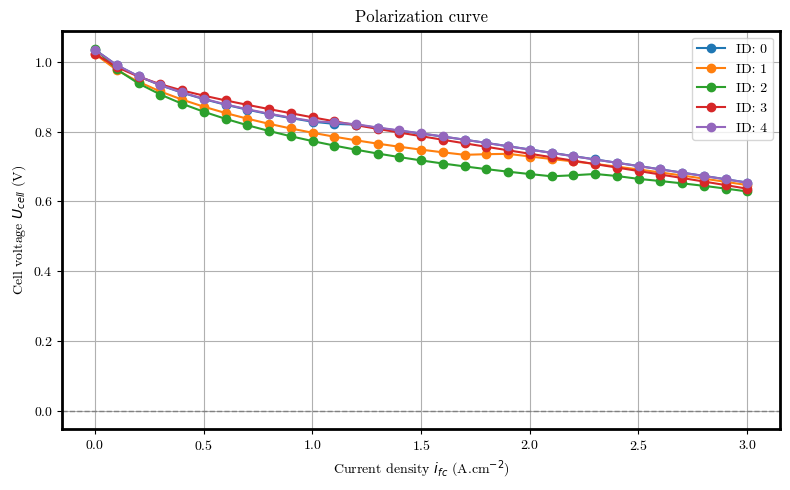

In [247]:
plot_polarization_curves(combined_df)

In [183]:
import pandas as pd

# Find all duplicates (keep=False keeps *all* instances)
duplicates = df_param_values[df_param_values.duplicated(keep=False)]

# Group by all columns and collect indices
grouped = (
    duplicates
    .groupby(list(df_param_values.columns), dropna=False)
    .apply(lambda g: list(g.index))
    .reset_index()
)

# Rename the last column to 'duplicate_indices'
grouped = grouped.rename(columns={0: 'duplicate_indices'})

# Optional: only show groups with more than 1 duplicate
grouped = grouped[grouped['duplicate_indices'].apply(len) > 1]

print(grouped)

             Tfc         Pa_des        Sc  Phi_c_des  epsilon_gdl       tau  \
0     333.001699  275025.262218  1.767599   0.414591     0.693786  3.326335   
1     333.041524  260392.561536  2.987177   0.378190     0.712556  1.744661   
2     333.053767  130229.127388  1.464752   0.111716     0.577274  2.132093   
3     333.071462  298527.131425  2.051457   0.375087     0.669403  3.089018   
4     333.096920  162916.284883  1.764791   0.670281     0.661206  2.457956   
...          ...            ...       ...        ...          ...       ...   
1531  362.932710  167676.784387  1.681646   0.264824     0.777165  3.597573   
1532  362.937597  137134.192232  2.725963   0.391441     0.577978  1.221371   
1533  362.956009  191247.382089  2.793845   0.661523     0.679864  1.370386   
1534  362.978658  169489.613594  2.433296   0.428046     0.665889  1.164821   
1535  362.999374  299637.402715  2.025997   0.685288     0.748438  1.949275   

      epsilon_mc  epsilon_c  e        Re   i0_c_ref

C:\Users\User\AppData\Local\Temp\ipykernel_25932\3932658985.py:10: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [184]:
grouped

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,duplicate_indices
0,333.001699,275025.262218,1.767599,0.414591,0.693786,3.326335,0.329296,0.248807,5,0.000001,27.433785,23.896149,1.173076,"[15120, 15129]"
1,333.041524,260392.561536,2.987177,0.378190,0.712556,1.744661,0.280212,0.182237,4,0.000003,40.120869,24.621971,2.474425,"[33454, 33459]"
2,333.053767,130229.127388,1.464752,0.111716,0.577274,2.132093,0.186531,0.257086,5,0.000005,59.103167,31.961493,2.487173,"[11390, 11395]"
3,333.071462,298527.131425,2.051457,0.375087,0.669403,3.089018,0.203423,0.292816,4,0.000002,34.734152,27.404561,1.913806,"[29456, 29465]"
4,333.096920,162916.284883,1.764791,0.670281,0.661206,2.457956,0.228190,0.185197,4,0.000004,78.791863,29.016767,1.505720,"[24802, 24807]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1531,362.932710,167676.784387,1.681646,0.264824,0.777165,3.597573,0.257457,0.198864,4,0.000005,5.148084,19.148964,0.065435,"[32732, 32741]"
1532,362.937597,137134.192232,2.725963,0.391441,0.577978,1.221371,0.389323,0.211242,4,0.000004,27.473521,17.493945,0.414860,"[18306, 18311]"
1533,362.956009,191247.382089,2.793845,0.661523,0.679864,1.370386,0.347761,0.226813,5,0.000001,43.080381,34.351915,0.501031,"[47068, 47077]"
1534,362.978658,169489.613594,2.433296,0.428046,0.665889,1.164821,0.275403,0.282622,3,0.000005,7.162265,20.828166,0.771309,"[3102, 3107]"


In [198]:
df_param_values[df_param_values.duplicated()]

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c


### Analysis of the samples we already have

In [47]:
df_sampled = pd.read_pickle("../sampling_test/validated_final_df_57344_imputed.pkl")
print(len(df_sampled))

df_sampled.head()

57344


,SHA256,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,...,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,classification
0,11170333c7cff3594b57670d910e23c0cfb512b9993b1f...,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,...,0.729581,0.720127,0.710685,0.701266,0.691858,0.682437,0.672987,0.663492,0.653933,valid
1,8e2c7334fc6d523390f9e223d856240c78e571a51f1f0c...,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,...,0.714529,0.707308,0.699520,0.691411,0.682963,0.674201,0.665215,0.656067,0.646718,valid
2,2d5bbaacfbbf0565bf81093360b4944766eca564d7f371...,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,...,0.674925,0.678619,0.672719,0.664526,0.658328,0.651771,0.644673,0.636798,0.628506,valid
3,6e4e3de84bc725483d930efb9067c9aea5d44bd64cc913...,345.931298,268431.866782,1.789658,0.132128,0.624495,3.51943,0.324434,0.240591,5,...,0.716600,0.706744,0.696881,0.686989,0.677044,0.667028,0.656922,0.646707,0.636362,valid
4,8f70543ab8533dbec57dafb0546082beb9108067814b0c...,345.931298,268431.866782,2.632068,0.145910,0.624495,3.51943,0.324434,0.240591,5,...,0.729362,0.719902,0.710475,0.701074,0.691673,0.682255,0.672806,0.663305,0.653740,valid


In [53]:
ifc_cols = [col for col in df_sampled.columns if col.startswith("ifc_")]
ucell_cols = [col for col in df_sampled.columns if col.startswith("Ucell_")]

REGIONS = {
    "activation": (0.0, 0.4),
    "ohmic": (0.4, 1.6),
    "mass_transport": (1.6, np.inf),
}

In [127]:
region_name = "activation"
region_bounds = REGIONS[region_name]   
# Compute region-specific AUC
target_name = f"AUC_{region_name}"
print(f"[INFO] Computing AUC target for region: {region_name}")
df_sampled[target_name] = df_sampled.apply(
    compute_region_auc, axis=1, args=(ifc_cols, ucell_cols, region_bounds, "zero")
)


[INFO] Computing AUC target for region: activation


In [128]:
df_sampled.head()

,SHA256,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,...,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,classification,AUC_activation
0,11170333c7cff3594b57670d910e23c0cfb512b9993b1f...,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,...,0.720127,0.710685,0.701266,0.691858,0.682437,0.672987,0.663492,0.653933,valid,0.293052
1,8e2c7334fc6d523390f9e223d856240c78e571a51f1f0c...,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,...,0.707308,0.699520,0.691411,0.682963,0.674201,0.665215,0.656067,0.646718,valid,0.288597
2,2d5bbaacfbbf0565bf81093360b4944766eca564d7f371...,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,...,0.678619,0.672719,0.664526,0.658328,0.651771,0.644673,0.636798,0.628506,valid,0.288625
3,6e4e3de84bc725483d930efb9067c9aea5d44bd64cc913...,345.931298,268431.866782,1.789658,0.132128,0.624495,3.51943,0.324434,0.240591,5,...,0.706744,0.696881,0.686989,0.677044,0.667028,0.656922,0.646707,0.636362,valid,0.291976
4,8f70543ab8533dbec57dafb0546082beb9108067814b0c...,345.931298,268431.866782,2.632068,0.145910,0.624495,3.51943,0.324434,0.240591,5,...,0.719902,0.710475,0.701074,0.691673,0.682255,0.672806,0.663305,0.653740,valid,0.293121


In [129]:
df_sampled[target_name].isna().sum()

np.int64(0)

In [79]:
df_sampled[df_sampled["AUC_activation"].isna()]

,SHA256,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,...,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,classification,AUC_activation
15000,1920a2f374cc59b14dbaa8f8cf936e5b7b20559edec77e...,344.816848,184388.228173,2.228055,0.244742,0.641935,3.528215,0.196861,0.221686,4,...,-5.747435,-5.832653,-5.934782,-6.050958,-6.178251,-6.311865,-6.452699,-6.597694,invalid,NaN
15154,1965a39da4bf3de1ade38fdd896c11e73ab39d32420d81...,348.525747,188462.744618,2.083277,0.374100,0.576139,3.988198,0.154378,0.181519,3,...,-35.252535,-36.174808,-37.100917,-38.024425,-38.941069,-39.848430,-40.745789,-41.632876,invalid,NaN
15162,728c2432af7d9a5266b36cfd9aba6ee241384fad5127ab...,348.525747,175699.218015,1.470443,0.201348,0.760022,3.988198,0.191369,0.154654,3,...,-19.437016,-19.752247,-20.041500,-20.303383,-20.498059,-20.288145,-20.467955,-20.672225,invalid,NaN
15163,a5e2413866afa53839d58492364d4095c2e5e2995a01e3...,352.168503,188462.744618,1.470443,0.201348,0.760022,3.988198,0.191369,0.154654,3,...,-20.629779,-20.993999,-21.333208,-21.648470,-21.940779,-22.211055,-22.460026,-22.687628,invalid,NaN
15164,9e6895d7960f87b8821266d307ff6a089089f84df32d16...,352.168503,175699.218015,2.083277,0.201348,0.760022,3.988198,0.191369,0.154654,3,...,-25.833872,-26.350958,-26.841914,-27.307771,-27.749477,-28.167914,-28.563901,-28.938203,invalid,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26150,d104a387c28729fd212ee2b7ea06593eac39175f804699...,353.767007,268992.865859,1.512327,0.361325,0.793787,3.735680,0.162812,0.292508,3,...,-17.507979,-18.058249,-18.598797,-19.130008,-19.652250,-20.165871,-20.671207,-21.168575,invalid,NaN
26252,69e15d633e6cf1f662efb826060583e5e187eb2e1ca65c...,361.542063,141394.299786,1.713082,0.690384,0.757721,3.868693,0.233796,0.283190,4,...,-6.839052,-7.025164,-7.204823,-7.378312,-7.545894,-7.707817,-7.864306,-8.015564,invalid,NaN
26254,5d4a7d84c0b7dcc2df636c7584218b0c0f9030eb9cb7eb...,361.542063,141394.299786,1.352910,0.690384,0.606286,3.868693,0.233796,0.283190,4,...,-5.549598,-5.478898,-5.554485,-5.628176,-5.683874,-5.746159,-5.827344,-5.923910,invalid,NaN
26259,b393658b5a372c17526c5d32bb9cca578aed05920109ad...,361.542063,141394.299786,1.352910,0.690384,0.757721,3.868693,0.233796,0.283190,4,...,-6.478407,-6.648124,-6.818004,-6.981847,-7.139832,-7.292025,-7.438417,-7.579594,invalid,NaN


In [81]:
df_sampled = df_sampled.fillna(0)

In [78]:
df_sampled.isna().sum()

SHA256              0
Tfc                 0
Pa_des              0
Sc                  0
Phi_c_des           0
                 ... 
Ucell_28            0
Ucell_29            0
Ucell_30            0
classification      0
AUC_activation    556
Length: 114, dtype: int64

In [82]:
Y = df_sampled[target_name].to_numpy()

In [66]:
type(Y)

numpy.ndarray

In [58]:
len(Y)

57344

In [75]:
Y

array([0.29305233, 0.28859656, 0.28862456, ..., 0.2964784 , 0.29580547,
       0.29371242], shape=(57344,))

In [83]:
Si = sobol.analyze(
    problem,
    Y,
    calc_second_order=True,   # or False, depending on what you want
    print_to_console=True     # optional
)

c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


                   ST   ST_conf
Tfc          0.173180  0.063890
Pa_des       0.148788  0.056729
Sc           0.084410  0.047253
Phi_c_des    0.116566  0.054232
epsilon_gdl  0.130944  0.066467
tau          0.397171  0.083113
epsilon_mc   0.222651  0.055624
epsilon_c    0.114537  0.057453
e            0.070671  0.046285
Re           0.098641  0.047586
i0_c_ref     0.246652  0.059766
kappa_co     0.095117  0.044092
kappa_c      0.170057  0.050610
                   S1   S1_conf
Tfc          0.027329  0.060987
Pa_des       0.015382  0.049528
Sc           0.003507  0.047046
Phi_c_des   -0.000506  0.026810
epsilon_gdl  0.025418  0.031357
tau          0.206021  0.116357
epsilon_mc   0.026619  0.053003
epsilon_c    0.000687  0.050037
e            0.015979  0.021827
Re          -0.019717  0.049926
i0_c_ref     0.152450  0.053514
kappa_co    -0.009692  0.053758
kappa_c      0.078711  0.032453
                            S2   S2_conf
(Tfc, Pa_des)        -0.000018  0.080365
(Tfc, Sc)             

In [71]:
Y

array([0.29305233, 0.28859656, 0.28862456, ..., 0.2964784 , 0.29580547,
       0.29371242], shape=(57344,))

In [67]:
Si = sobol.analyze(problem, Y)

c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


In [84]:
total_Si, first_Si, second_Si = Si.to_df()

c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


In [85]:
first_Si

,S1,S1_conf
Tfc,0.027329,0.060987
Pa_des,0.015382,0.049528
Sc,0.003507,0.047046
Phi_c_des,-0.000506,0.026810
epsilon_gdl,0.025418,0.031357
tau,0.206021,0.116357
epsilon_mc,0.026619,0.053003
epsilon_c,0.000687,0.050037
e,0.015979,0.021827
Re,-0.019717,0.049926


In [88]:
first_Si.sort_values(by = "S1", ascending=False)

,S1,S1_conf
tau,0.206021,0.116357
i0_c_ref,0.152450,0.053514
kappa_c,0.078711,0.032453
Tfc,0.027329,0.060987
epsilon_mc,0.026619,0.053003
epsilon_gdl,0.025418,0.031357
e,0.015979,0.021827
Pa_des,0.015382,0.049528
Sc,0.003507,0.047046
epsilon_c,0.000687,0.050037


In [89]:
sum(first_Si["S1"])

0.522187220178953

In [130]:
print(sum(second_Si["S2"]))
second_Si["S2"]

0.7891167826822554


(Tfc, Pa_des)          -0.000018
(Tfc, Sc)               0.010086
(Tfc, Phi_c_des)        0.026554
(Tfc, epsilon_gdl)      0.009473
(Tfc, tau)              0.037272
                          ...   
(Re, kappa_co)          0.019869
(Re, kappa_c)           0.016732
(i0_c_ref, kappa_co)    0.025434
(i0_c_ref, kappa_c)     0.013240
(kappa_co, kappa_c)     0.025692
Name: S2, Length: 78, dtype: float64

In [86]:
sum(first_Si["S1"]) + sum(second_Si["S2"])

1.3113040028612084

In [91]:
for i, name in enumerate(problem['names']):
    print(f"{name:12s} | S1 = {Si['S1'][i]:.3f} ± {Si['S1_conf'][i]:.3f}, "
          f"ST = {Si['ST'][i]:.3f} ± {Si['ST_conf'][i]:.3f}")

Tfc          | S1 = 0.027 ± 0.061, ST = 0.173 ± 0.064
Pa_des       | S1 = 0.015 ± 0.050, ST = 0.149 ± 0.057
Sc           | S1 = 0.004 ± 0.047, ST = 0.084 ± 0.047
Phi_c_des    | S1 = -0.001 ± 0.027, ST = 0.117 ± 0.054
epsilon_gdl  | S1 = 0.025 ± 0.031, ST = 0.131 ± 0.066
tau          | S1 = 0.206 ± 0.116, ST = 0.397 ± 0.083
epsilon_mc   | S1 = 0.027 ± 0.053, ST = 0.223 ± 0.056
epsilon_c    | S1 = 0.001 ± 0.050, ST = 0.115 ± 0.057
e            | S1 = 0.016 ± 0.022, ST = 0.071 ± 0.046
Re           | S1 = -0.020 ± 0.050, ST = 0.099 ± 0.048
i0_c_ref     | S1 = 0.152 ± 0.054, ST = 0.247 ± 0.060
kappa_co     | S1 = -0.010 ± 0.054, ST = 0.095 ± 0.044
kappa_c      | S1 = 0.079 ± 0.032, ST = 0.170 ± 0.051


In [133]:
first_Si.sort_values(by = "S1", ascending = False)

,S1,S1_conf
tau,0.206021,0.116357
i0_c_ref,0.152450,0.053514
kappa_c,0.078711,0.032453
Tfc,0.027329,0.060987
epsilon_mc,0.026619,0.053003
epsilon_gdl,0.025418,0.031357
e,0.015979,0.021827
Pa_des,0.015382,0.049528
Sc,0.003507,0.047046
epsilon_c,0.000687,0.050037


In [131]:
total_Si.sort_values(by = "ST", ascending = False)

,ST,ST_conf
tau,0.397171,0.083113
i0_c_ref,0.246652,0.059766
epsilon_mc,0.222651,0.055624
Tfc,0.173180,0.063890
kappa_c,0.170057,0.050610
Pa_des,0.148788,0.056729
epsilon_gdl,0.130944,0.066467
Phi_c_des,0.116566,0.054232
epsilon_c,0.114537,0.057453
Re,0.098641,0.047586


In [124]:
import plotly.graph_objects as go

fig = go.Figure()

for name in problem['names']:
    fig.add_trace(go.Scatter(
        x=n_effective,
        y=st_convergence[name],
        mode='lines+markers',
        name=name
    ))

fig.update_layout(
    title='Convergence of Total Sobol Indices (ST) vs. Sample Size',
    xaxis_title='N (base sample size)',
    yaxis_title='Sobol ST index',
    hovermode='x unified',
    legend=dict(
        orientation='v',
        x=1.02,
        y=1,
        xanchor='left',
        yanchor='top'
    ),
    width=1000,
    height=600,
    margin=dict(r=150)
)

fig.show()

In [119]:
len(Y)

57344

In [121]:
# Settings
D = 13
step = 128  # step size for N (e.g., 128, 256, 512, ...)
max_N = 2048
samples_per_N = 2*D + 2
N_values = list(range(step, max_N + 1, step))

# Store convergence data
st_convergence = {name: [] for name in problem['names']}
n_effective = []

for N_i in N_values:
    end_idx = N_i * samples_per_N
    Y_subset = Y[:end_idx]
    
    try:
        Si = sobol.analyze(problem, Y_subset, calc_second_order=True, print_to_console=False)
        for i, name in enumerate(problem['names']):
            st_convergence[name].append(Si['ST'][i])
        n_effective.append(N_i)
    except Exception as e:
        print(f"Failed at N={N_i}: {e}")

c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



In [123]:
total_Si

,ST,ST_conf
Tfc,0.173180,0.063890
Pa_des,0.148788,0.056729
Sc,0.084410,0.047253
Phi_c_des,0.116566,0.054232
epsilon_gdl,0.130944,0.066467
tau,0.397171,0.083113
epsilon_mc,0.222651,0.055624
epsilon_c,0.114537,0.057453
e,0.070671,0.046285
Re,0.098641,0.047586


In [122]:
Si["ST"]

array([0.17317981, 0.14878782, 0.08441042, 0.11656647, 0.13094442,
       0.39717113, 0.22265063, 0.11453671, 0.07067079, 0.09864106,
       0.24665193, 0.09511672, 0.17005688])

In [134]:
import numpy as np
import pandas as pd

def auc_per_region_dataframe(data, bins=[0, 0.4, 1.6, np.inf]):
    """
    Compute AUC for each of the three regions (activation, ohmic, mass)
    defined by bins over current density (`ifc`), for all rows in the DataFrame.

    Parameters
    ----------
    data : pd.DataFrame
        Must contain columns 'Ucell' and 'ifc', each a list/array of floats.
    bins : list of float
        4 strictly increasing values defining 3 regions.

    Returns
    -------
    pd.DataFrame
        One row per input row, with columns ['AUC_activation', 'AUC_ohmic', 'AUC_mass']
    """
    # Validate bins
    if not isinstance(bins, (list, tuple, np.ndarray)):
        raise TypeError("`bins` must be a list, tuple, or numpy array.")
    if len(bins) != 4:
        raise ValueError("`bins` must contain exactly 4 numeric values to define 3 regions.")
    if not all(isinstance(b, (int, float, np.integer, np.floating)) for b in bins):
        raise TypeError("All elements in `bins` must be numeric.")
    if not all(bins[i] < bins[i + 1] for i in range(len(bins) - 1)):
        raise ValueError("`bins` must be strictly increasing.")

    # Use first row's ifc to define bin edges (assuming all rows have same structure)
    labels = ['activation', 'ohmic', 'mass']
    grouped = pd.cut(data['ifc'].iloc[0], bins=bins, labels=labels, right=False)
    num_bins = grouped.value_counts()

    regions = [
        (0, num_bins['activation']),
        (num_bins['activation'] + 1, num_bins['activation'] + 1 + num_bins['ohmic']),
        (num_bins['activation'] + 1 + num_bins['ohmic'], -1)
    ]
    regions = [(int(start), int(end)) for start, end in regions]

    # Define helper to compute region AUCs
    def auc_ucell_regions(ucell, ifc, regions):
        return [
            np.trapezoid(ifc[start:end + 1], x=ucell[start:end + 1]) if end != -1 else
            np.trapezoid(ifc[start:], x=ucell[start:])
            for start, end in regions
        ]

    # Apply row-wise
    def safe_auc(row):
        ucell, ifc = row['Ucell'], row['ifc']
        if isinstance(ucell, (list, np.ndarray)) and isinstance(ifc, (list, np.ndarray)):
            return auc_ucell_regions(ucell, ifc, regions)
        else:
            return [np.nan, np.nan, np.nan]

    auc_values = data.apply(safe_auc, axis=1, result_type='expand')
    auc_values.columns = ['AUC_activation', 'AUC_ohmic', 'AUC_mass']
    return auc_values


In [147]:
region_aucs_mine = df_sampled.apply(
    lambda row: [
        compute_region_auc(row, ifc_cols, ucell_cols, (0, 0.4), handle_negative= "zero"),
        compute_region_auc(row, ifc_cols, ucell_cols, (0.4, 1.6), handle_negative= "zero"),
        compute_region_auc(row, ifc_cols, ucell_cols, (1.6, np.inf),handle_negative= "zero"),
    ],
    axis=1,
    result_type='expand'
)
region_aucs_mine.columns = ['AUC_activation', 'AUC_ohmic', 'AUC_mass']

In [148]:
region_aucs_mine["AUC_activation_keep_mine"] = df_sampled.apply(
    compute_region_auc, axis=1, args=(ifc_cols, ucell_cols, REGIONS["activation"], "keep")
)

In [158]:
def auc_per_region_fixed_bins(data, bins=[0, 0.4, 1.6, np.inf]):
    """
    Compute AUC for each region (activation, ohmic, mass) using current-density bin thresholds.
    Applies np.trapezoid per region using actual 'ifc' values from each row.

    Parameters
    ----------
    data : pd.DataFrame
        Must contain columns 'Ucell' and 'ifc', each a list/array of floats.
    bins : list of float
        Thresholds for region splitting (default = [0, 0.4, 1.6, ∞]).

    Returns
    -------
    pd.DataFrame
        AUC per region: ['AUC_activation', 'AUC_ohmic', 'AUC_mass']
    """
    labels = ['activation', 'ohmic', 'mass']
    if len(bins) != 4:
        raise ValueError("Bins must have exactly 4 values (to define 3 regions).")

    def auc_row(row):
        ucell = row['Ucell']
        ifc = row['ifc']
        if not isinstance(ucell, (list, np.ndarray)) or not isinstance(ifc, (list, np.ndarray)):
            return [np.nan] * 3

        aucs = []
        for lower, upper in zip(bins[:-1], bins[1:]):
            mask = (ifc >= lower) & (ifc < upper)
            if np.any(mask):
                aucs.append(np.trapezoid(ifc[mask], ucell[mask]))
            else:
                aucs.append(np.nan)
        return aucs

    auc_values = data.apply(auc_row, axis=1, result_type='expand')
    auc_values.columns = ['AUC_activation', 'AUC_ohmic', 'AUC_mass']
    return auc_values

In [159]:
# region_aucs_friend = auc_per_region_dataframe(df_sampled)
region_aucs_friend = auc_per_region_fixed_bins(df_sampled)

In [163]:
region_aucs_friend

,AUC_activation,AUC_ohmic,AUC_mass
0,-0.013436,-0.098892,-0.303133
1,-0.014296,-0.123384,-0.228598
2,-0.016972,-0.140111,-0.185976
3,-0.011466,-0.120130,-0.322494
4,-0.013315,-0.099796,-0.304204
...,...,...,...
57339,-0.016799,-0.137610,-0.331526
57340,-0.017727,-0.158960,-0.396720
57341,-0.018990,-0.160237,-0.397576
57342,-0.017792,-0.160553,-0.402358


In [160]:
comparison = pd.concat([region_aucs_friend, region_aucs_mine.add_suffix('_mine')], axis=1)
comparison.head()

,AUC_activation,AUC_ohmic,AUC_mass,AUC_activation_mine,AUC_ohmic_mine,AUC_mass_mine,AUC_activation_keep_mine_mine
0,-0.013436,-0.098892,-0.303133,0.293052,0.925458,1.008128,0.293052
1,-0.014296,-0.123384,-0.228598,0.288597,0.888930,0.983934,0.288597
2,-0.016972,-0.140111,-0.185976,0.288625,0.864168,0.937877,0.288625
3,-0.011466,-0.120130,-0.322494,0.291976,0.932929,0.989277,0.291976
4,-0.013315,-0.099796,-0.304204,0.293121,0.927037,1.007956,0.293121


In [162]:
comparison[comparison["AUC_activation_mine"] != comparison["AUC_activation_keep_mine_mine"]][["AUC_activation", "AUC_activation_mine", "AUC_activation_keep_mine_mine"]]

,AUC_activation,AUC_activation_mine,AUC_activation_keep_mine_mine
15000,-0.310674,0.034560,-0.147664
15001,-0.256259,0.044758,-0.060985
15002,-0.253723,0.045024,-0.059255
15003,-0.252503,0.045481,-0.057666
15004,-0.253723,0.044318,-0.060667
...,...,...,...
26254,-0.205442,0.024870,-0.070768
26259,-0.209515,0.024854,-0.073629
26261,-0.214699,0.047525,-0.027584
26262,-0.211074,0.024452,-0.077586


<Axes: >

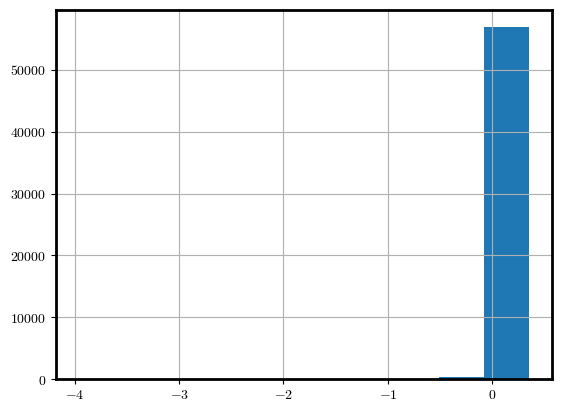

In [157]:
comparison["AUC_activation_keep_mine_mine"].hist()

<Axes: >

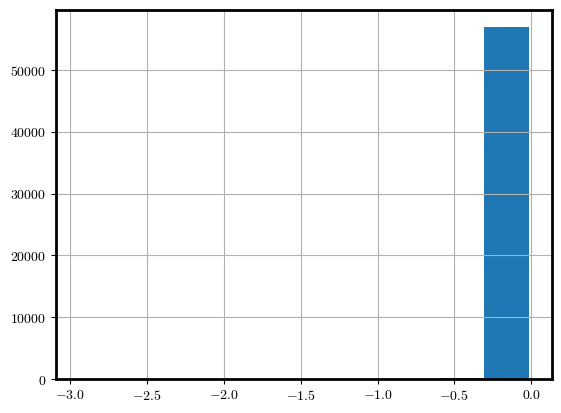

In [155]:
comparison["AUC_activation"].hist()

In [136]:
region_aucs_mine

,AUC_activation,AUC_ohmic,AUC_mass
0,0.293052,0.925458,1.008128
1,0.288597,0.888930,0.983934
2,0.288625,0.864168,0.937877
3,0.291976,0.932929,0.989277
4,0.293121,0.927037,1.007956
...,...,...,...
57339,0.295041,0.896810,0.926782
57340,0.308398,0.927783,0.927801
57341,0.296478,0.877287,0.862510
57342,0.295805,0.880376,0.864422


In [ ]:
comparison = region_aucs_mine.